<a href="https://colab.research.google.com/github/Koel09/DS_Classification_FertilizerRecommendation/blob/main/Fertilizer_Recommendation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
from google.colab import files
uploaded = files.upload()

Saving fertilizer_recommendation_dataset.csv to fertilizer_recommendation_dataset.csv


In [3]:
# Load dataset
df = pd.read_csv('fertilizer_recommendation_dataset.csv')

# Display dataset info
df.head()

,Temperature,Moisture,Rainfall,PH,Nitrogen,Phosphorous,Potassium,Carbon,Soil,Crop,Fertilizer,Remark
0,50.179845,0.725893,205.600816,6.227358,66.701872,76.963560,96.429065,0.496300,Loamy Soil,rice,Compost,Enhances organic matter and improves soil stru...
1,21.633318,0.721958,306.081601,7.173131,71.583316,163.057636,148.128347,1.234242,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
2,23.060964,0.685751,259.336414,7.380793,75.709830,62.091508,80.308971,1.795650,Peaty Soil,rice,Water Retaining Fertilizer,Improves water retention in dry soils. Prefer ...
3,26.241975,0.755095,212.703513,6.883367,78.033687,151.012521,153.005712,1.517556,Loamy Soil,rice,Balanced NPK Fertilizer,"Provides a balanced mix of nitrogen, phosphoru..."
4,21.490157,0.730672,268.786767,7.578760,71.765123,66.257371,97.000886,1.782985,Peaty Soil,rice,Organic Fertilizer,"Enhances fertility naturally, ideal for peaty ..."


In [4]:
# check for null values
df.isnull().sum()

,0
Temperature,0
Moisture,0
Rainfall,0
PH,0
Nitrogen,0
Phosphorous,0
Potassium,0
Carbon,0
Soil,0
Crop,0


In [5]:
# check for datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3100 entries, 0 to 3099
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  3100 non-null   float64
 1   Moisture     3100 non-null   float64
 2   Rainfall     3100 non-null   float64
 3   PH           3100 non-null   float64
 4   Nitrogen     3100 non-null   float64
 5   Phosphorous  3100 non-null   float64
 6   Potassium    3100 non-null   float64
 7   Carbon       3100 non-null   float64
 8   Soil         3100 non-null   object 
 9   Crop         3100 non-null   object 
 10  Fertilizer   3100 non-null   object 
 11  Remark       3100 non-null   object 
dtypes: float64(8), object(4)
memory usage: 290.8+ KB


In [6]:
# Encoding object columns

df['Soil_index'] = df['Soil'].astype('category').cat.codes
df['Crop_index'] = df['Crop'].astype('category').cat.codes
df['Fertilizer_index'] = df['Fertilizer'].astype('category').cat.codes

# Get unique values from each column
unique_Soil = df['Soil'].drop_duplicates().reset_index(drop=True)
unique_Soil_indices = df['Soil_index'].drop_duplicates().reset_index(drop=True)

# Create a new DataFrame with both columns
mapping_Soil_df = pd.DataFrame({
    'unique_Soil': unique_Soil,
    'unique_Soil_indices': unique_Soil_indices
})
# mapping_Soil_df

# Get unique values from each column
unique_Crop = df['Crop'].drop_duplicates().reset_index(drop=True)
unique_Crop_indices = df['Crop_index'].drop_duplicates().reset_index(drop=True)

# Create a new DataFrame with both columns
mapping_Crop_df = pd.DataFrame({
    'unique_Crop': unique_Crop,
    'unique_Crop_indices': unique_Crop_indices
})
# mapping_Crop_df

# Get unique values from each column
unique_Fertilizer = df['Fertilizer'].drop_duplicates().reset_index(drop=True)
unique_Fertilizer_indices = df['Fertilizer_index'].drop_duplicates().reset_index(drop=True)

# Create a new DataFrame with both columns
mapping_Fertilizer_df = pd.DataFrame({
    'unique_Fertilizer': unique_Fertilizer,
    'unique_Fertilizer_indices': unique_Fertilizer_indices
})
# mapping_Fertilizer_df

# Selecting only numeric columns
# Select only numeric columns before correlation
numeric_df = df.select_dtypes(include=['number'])

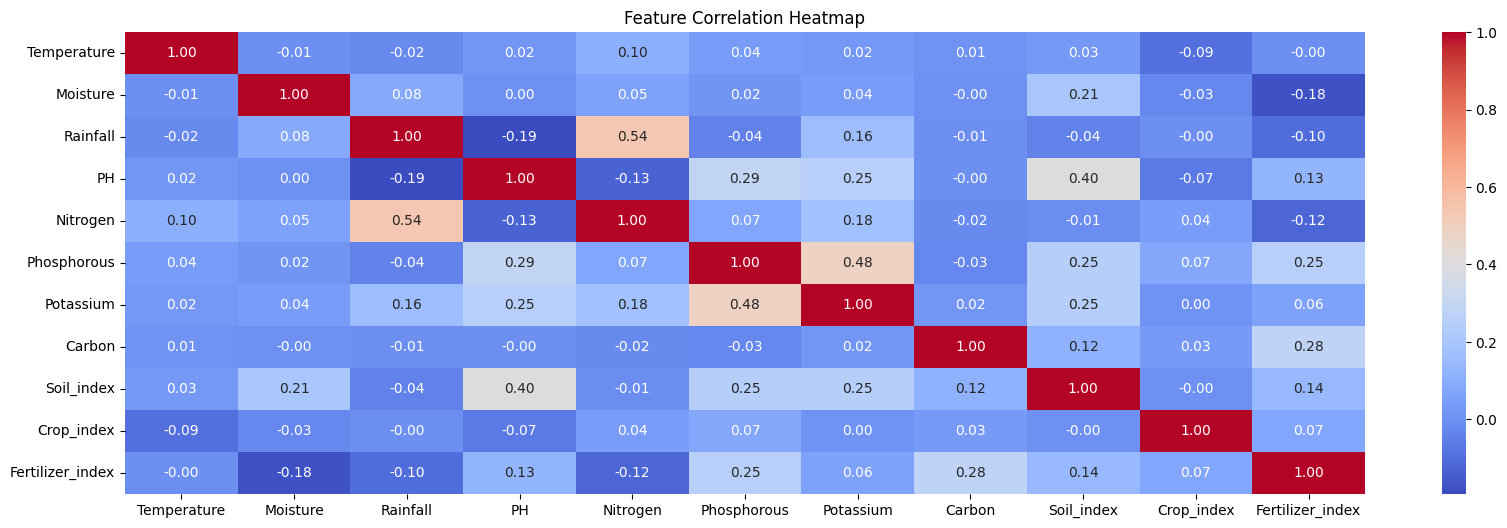

In [7]:
# Correlation heatmap
plt.figure(figsize=(20, 6))

# Create heatmap with only numeric columns
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

<Figure size 2000x600 with 0 Axes>

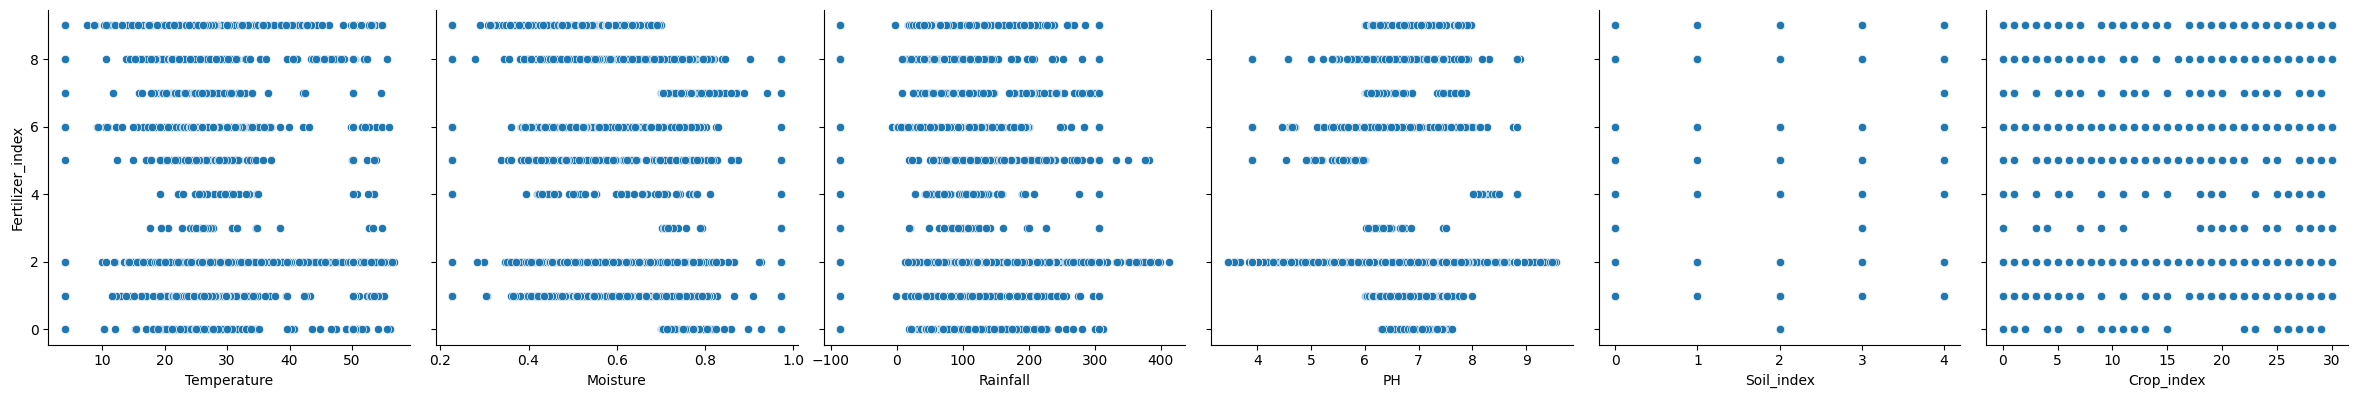

In [8]:
# Boxplot to detect outliers
plt.figure(figsize=(20, 6))
#plot all the scatterplots in a single plot
sns.pairplot(numeric_df, x_vars=['Temperature','Moisture','Rainfall','PH','Soil_index','Crop_index'], y_vars = 'Fertilizer_index', height = 4, kind = 'scatter' )
plt.show()

<Figure size 2000x600 with 0 Axes>

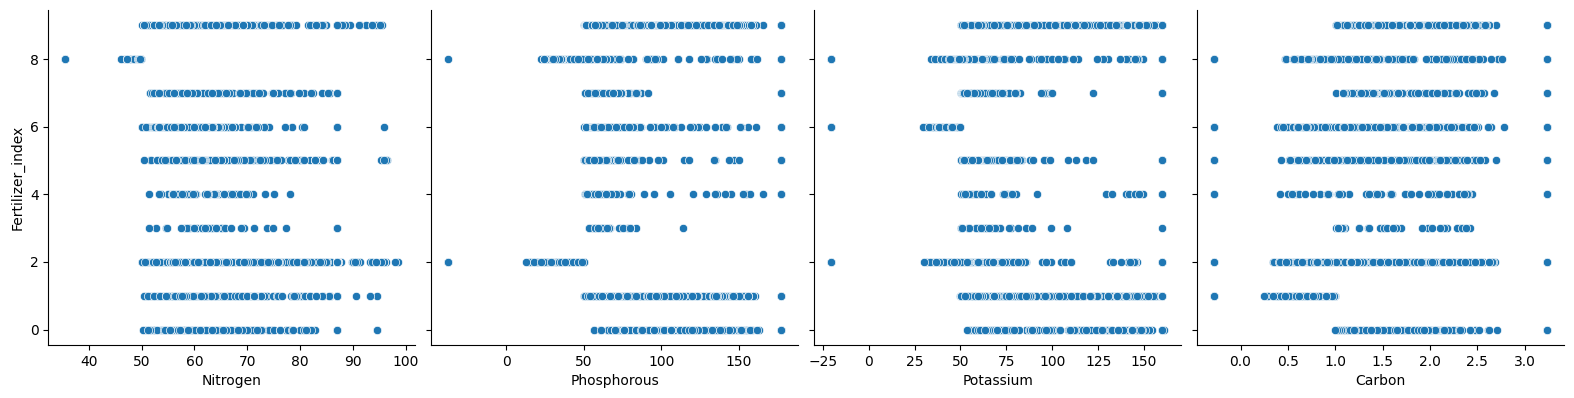

In [9]:
# Boxplot to detect outliers
plt.figure(figsize=(20, 6))
#plot all the scatterplots in a single plot
sns.pairplot(numeric_df, x_vars=['Nitrogen','Phosphorous','Potassium','Carbon'], y_vars = 'Fertilizer_index', height = 4, kind = 'scatter' )
plt.show()

In [10]:
# Feature selection
from sklearn.feature_selection import SelectKBest, f_classif

# splitting label and features
X=numeric_df.drop('Fertilizer_index', axis=1)
y=numeric_df['Fertilizer_index']

# applying feature selection
selector = SelectKBest(score_func=f_classif, k=6)
X_selected=selector.fit_transform(X,y)
selected_features=X.columns[selector.get_support()]

# created df with selected features ('Moisture','Rainfall','PH','Nitrogen','Phosphorous','Carbon','Soil_index')
Xs=numeric_df[selected_features]
# Xs=numeric_df[['Moisture','Rainfall','PH','Nitrogen','Phosphorous','Carbon','Soil_index']]

In [11]:
# Import the StandardScaler class from scikit-learn
from sklearn.preprocessing import StandardScaler, RobustScaler

# Feature scaling
# scaler = StandardScaler() # Robust scaler deal with outliers
scaler = RobustScaler()
Xs_scaled = scaler.fit_transform(Xs)

In [12]:
from imblearn.over_sampling import SMOTE

#check for dataset imbalance
# print('number of samples in each class:')
# numeric_df['Fertilizer_index'].value_counts()

#Balancing the Dataset (SMOTE: Oversampling using imblearn library)
smote = SMOTE(random_state=42)
Xs_balanced, y_balanced = smote.fit_resample(Xs_scaled, y)

In [13]:
# train test split
from sklearn.model_selection import train_test_split

Xs_train, Xs_test, y_train, y_test=train_test_split(Xs_balanced,y_balanced,test_size=0.3,random_state=42)

In [14]:
# Model to be considered for multiclass classification
# Logistic regression(OVR), KNN, SVM, Random forest , gradient boosting

In [15]:
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, log_loss, roc_auc_score, roc_curve
)

# Model Evaluation Metrics
def evaluate_model(y_true, y_pred):
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# Logistic Regression (One-vs-Rest)
lr_ovr = OneVsRestClassifier(LogisticRegression())
lr_ovr.fit(Xs_train, y_train)
y_pred_lr_ovr = lr_ovr.predict(Xs_test)

# Evaluate Logistic Regression (OvR)
evaluate_model(y_test, y_pred_lr_ovr)

Confusion Matrix:
[[239   2   0  15   2   0  10  39   4   0]
 [  1 289   1   6   5   5   5   0   1   1]
 [  0  14 234   7  18  24  25   2   9   5]
 [  3  11   0 210   0   6   6  93   0   0]
 [  2   2   0   0 318   0   0   0   0   0]
 [  5  41   1  21   0 148  17  32   0  27]
 [  0  17   0  11   9  17 249   3   1  10]
 [ 16   0   5  95   5   2  26 180   2   0]
 [  0   1   5   0   0   0   5   0 308   0]
 [ 22  15   3   0   3  24  16  20   3 183]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       311
           1       0.74      0.92      0.82       314
           2       0.94      0.69      0.80       338
           3       0.58      0.64      0.61       329
           4       0.88      0.99      0.93       322
           5       0.65      0.51      0.57       292
           6       0.69      0.79      0.74       317
           7       0.49      0.54      0.51       331
           8       0.94      0.97      0

In [17]:
from sklearn.svm import SVC

svm=SVC(kernel='rbf', probability=True,random_state=42 )
svm.fit(Xs_train,y_train)
y_pred_svm=svm.predict(Xs_test)

# Evaluate SVM
evaluate_model(y_test, y_pred_svm)

Confusion Matrix:
[[289   1   0   8   0   0   0  13   0   0]
 [  0 304   0   2   1   5   0   0   1   1]
 [  0   3 276   0   3  18  20   2  14   2]
 [  0   0   0 266   0   1   0  62   0   0]
 [  0   0   0   0 322   0   0   0   0   0]
 [  0   0   1   0   0 284   2   5   0   0]
 [  0   2   3   0   5   5 297   5   0   0]
 [ 10   0   0  21   0   2   1 297   0   0]
 [  0   0   0   0   0   0   3   0 315   1]
 [ 10   6   0  11   1  11   7   1   0 242]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       311
           1       0.96      0.97      0.97       314
           2       0.99      0.82      0.89       338
           3       0.86      0.81      0.84       329
           4       0.97      1.00      0.98       322
           5       0.87      0.97      0.92       292
           6       0.90      0.94      0.92       317
           7       0.77      0.90      0.83       331
           8       0.95      0.99      0

In [18]:
from sklearn.neighbors import KNeighborsClassifier

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(Xs_train,y_train)
y_pred_knn=knn.predict(Xs_test)

# Evaluate KNN algorithm
evaluate_model(y_test, y_pred_knn)

Confusion Matrix:
[[305   1   0   0   0   0   0   5   0   0]
 [  5 294   0   2   1   2   2   3   1   4]
 [  0   9 214   7   5  45  30   4  19   5]
 [  1   0   0 323   0   0   0   5   0   0]
 [  0   0   0   0 322   0   0   0   0   0]
 [  0   1   2   0   0 284   0   5   0   0]
 [  0   6   5   3   1   5 289   7   0   1]
 [  1   0   0   3   0   1   0 326   0   0]
 [  0   0   2   0   0   0   0   0 317   0]
 [ 11  16   0   9   1   8   6  11   0 227]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96       311
           1       0.90      0.94      0.92       314
           2       0.96      0.63      0.76       338
           3       0.93      0.98      0.96       329
           4       0.98      1.00      0.99       322
           5       0.82      0.97      0.89       292
           6       0.88      0.91      0.90       317
           7       0.89      0.98      0.94       331
           8       0.94      0.99      0

In [19]:
from sklearn.ensemble import RandomForestClassifier

#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(Xs_train, y_train)
y_pred_rf = rf.predict(Xs_test)

evaluate_model(y_test, y_pred_rf)

Confusion Matrix:
[[308   0   0   1   0   0   0   2   0   0]
 [  0 314   0   0   0   0   0   0   0   0]
 [  0   0 338   0   0   0   0   0   0   0]
 [  0   0   0 328   0   0   0   1   0   0]
 [  0   0   0   0 322   0   0   0   0   0]
 [  0   0   0   0   0 292   0   0   0   0]
 [  0   1   0   0   0   0 316   0   0   0]
 [  8   0   0   0   0   0   0 323   0   0]
 [  0   0   0   0   0   0   0   0 319   0]
 [  0   0   0   0   0   0   0   0   0 289]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       311
           1       1.00      1.00      1.00       314
           2       1.00      1.00      1.00       338
           3       1.00      1.00      1.00       329
           4       1.00      1.00      1.00       322
           5       1.00      1.00      1.00       292
           6       1.00      1.00      1.00       317
           7       0.99      0.98      0.98       331
           8       1.00      1.00      1

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

#Gradient Boosting Trees (GBT)
gbt = GradientBoostingClassifier(random_state=42)
gbt.fit(Xs_train, y_train)
y_pred_gbt = gbt.predict(Xs_test)

evaluate_model(y_test, y_pred_gbt)

Confusion Matrix:
[[304   0   0   1   0   0   0   6   0   0]
 [  0 314   0   0   0   0   0   0   0   0]
 [  0   0 338   0   0   0   0   0   0   0]
 [  0   0   0 311   0   0   0  18   0   0]
 [  0   0   0   0 322   0   0   0   0   0]
 [  0   0   0   0   0 290   0   0   0   2]
 [  0   1   0   0   0   0 316   0   0   0]
 [ 12   0   0   1   0   0   0 318   0   0]
 [  0   0   0   0   0   0   0   0 319   0]
 [  0   0   0   0   0   0   0   0   0 289]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       311
           1       1.00      1.00      1.00       314
           2       1.00      1.00      1.00       338
           3       0.99      0.95      0.97       329
           4       1.00      1.00      1.00       322
           5       1.00      0.99      1.00       292
           6       1.00      1.00      1.00       317
           7       0.93      0.96      0.95       331
           8       1.00      1.00      1

In [21]:
# Model Comparison
models = {
    'Logistic regression (OvR)':lr_ovr,
    'Support vector classification': svm,
    'K-nearest neighbor': knn,
    'Random Forest': rf,
    'Gradient Boosting': gbt
}

metrics = []

for name, model in models.items():
    y_pred = model.predict(Xs_test)
    metrics.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1': f1_score(y_test, y_pred, average='macro')
    })

metrics_df = pd.DataFrame(metrics)
print("\nModel Comparison:")
metrics_df


Model Comparison:


,Model,Accuracy,Precision,Recall,F1
0,Logistic regression (OvR),0.745731,0.755057,0.744193,0.743687
1,Support vector classification,0.914611,0.919741,0.915412,0.915260
2,K-nearest neighbor,0.917457,0.920574,0.918028,0.913995
3,Random Forest,0.995889,0.995927,0.995999,0.995950
4,Gradient Boosting,0.987034,0.987541,0.987350,0.987351


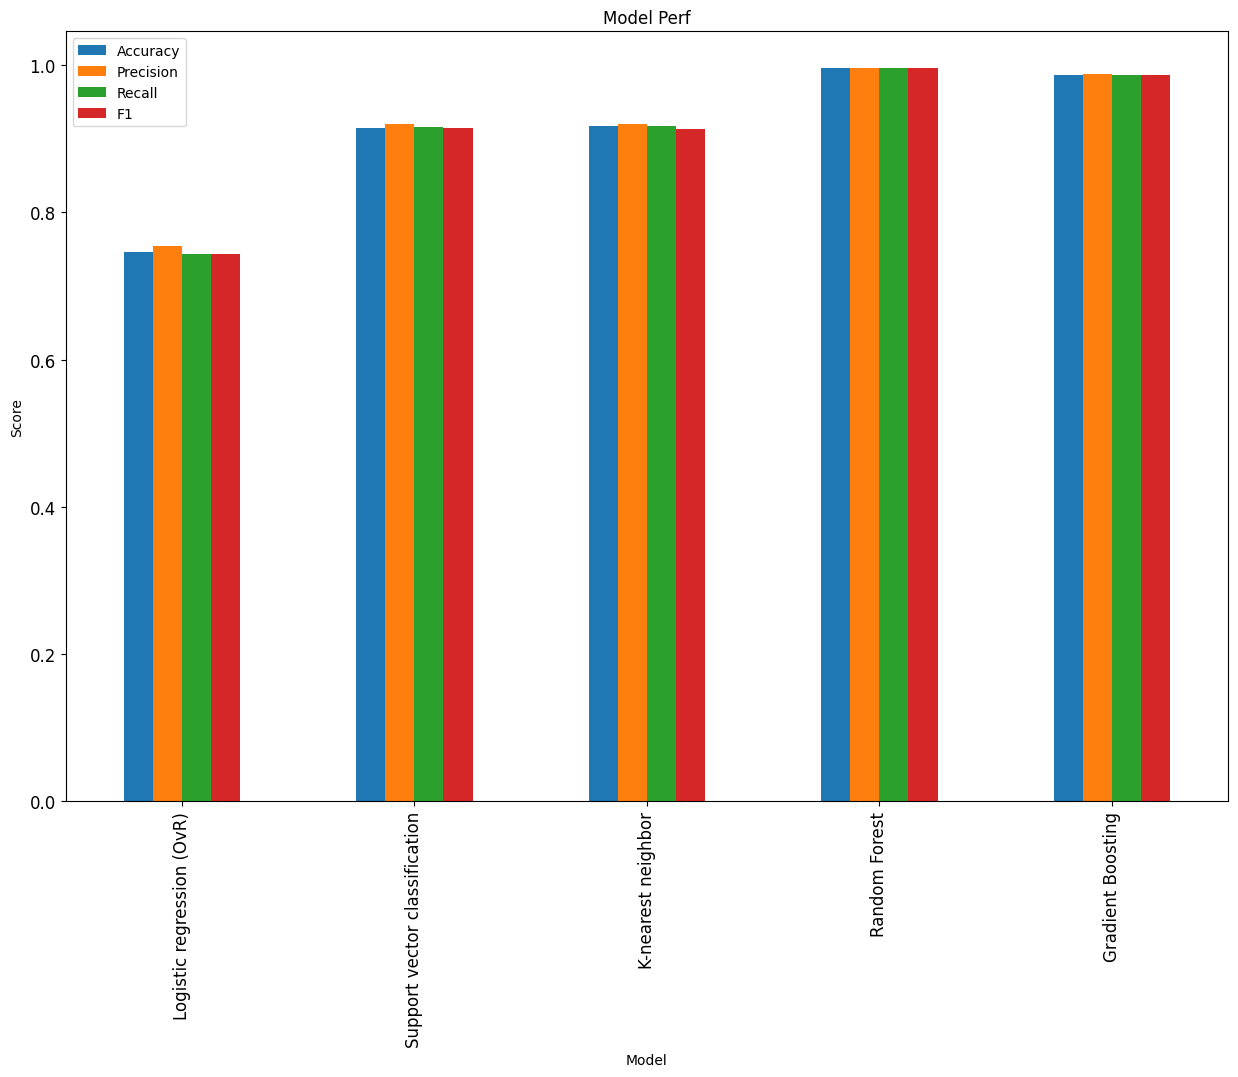

In [22]:
metrics_bar = metrics_df.plot(x='Model', y= ['Accuracy','Precision','Recall','F1'],kind='bar', title ="Model Perf",
                              figsize=(15, 10),xlabel='Model', ylabel='Score', legend=True, fontsize=12)
plt.show()